In [1]:
import tensorflow as tf
import numpy as np
import time, gc, os, json, warnings, struct, gzip
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

✓ GPUs: 2
LOADING CONVEX DATASET
[!] Dataset tidak ditemukan. Mencoba download...
    /kaggle/working/convex_train.amat: 8000 baris
    /kaggle/working/50k/convex_test.amat: 50000 baris
[✓] Train: (8000, 28, 28, 1) | Test: (50000, 28, 28, 1)
Full train : (8000, 28, 28, 1) | label unik: [0 1]
Full test  : (50000, 28, 28, 1)  | Kelas: ['Non-Convex', 'Convex']

Subset — Train: (7000, 28, 28, 1) | Val: (1000, 28, 28, 1) | Test: (50000, 28, 28, 1)

NS-LOA: Multi-Objective CNN — Convex Dataset (Dual GAP)

GENERATION 1/6


I0000 00:00:1790070460.815867      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790070460.818732      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1790070479.593475     129 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    ↻ Rescue: acc=0.5110 — retry dengan lr=2.03e-04
  Lion  1/10: acc=0.5110 | inf=4.40ms | size=7.89MB
    ↻ Rescue: acc=0.5110 — retry dengan lr=3.72e-04
  Lion  2/10: acc=0.5110 | inf=6.80ms | size=12.65MB
    ↻ Rescue: acc=0.5110 — retry dengan lr=6.07e-05
  Lion  3/10: acc=0.5110 | inf=6.85ms | size=12.89MB
    ↻ Rescue: acc=0.5110 — retry dengan lr=3.95e-05
  Lion  4/10: acc=0.5110 | inf=12.45ms | size=1.61MB
    ↻ Rescue: acc=0.5110 — retry dengan lr=1.94e-04
  Lion  5/10: acc=0.5110 | inf=18.65ms | size=1.51MB
    ↻ Rescue: acc=0.5110 — retry dengan lr=3.58e-05
  Lion  6/10: acc=0.5110 | inf=15.66ms | size=1.41MB
    ↻ Rescue: acc=0.5110 — retry dengan lr=1.86e-04
  Lion  7/10: acc=0.5110 | inf=5.41ms | size=9.37MB
    ↻ Rescue: acc=0.5110 — retry dengan lr=3.53e-05
  Lion  8/10: acc=0.5110 | inf=12.08ms | size=3.08MB
    ↻ Rescue: acc=0.5110 — retry dengan lr=7.41e-05
  Lion  9/10: acc=0.5110 | inf=18.62ms | size=2.91MB
    ↻ Rescue: acc=0.5110 — retry dengan lr=2.23e-04
  Lio

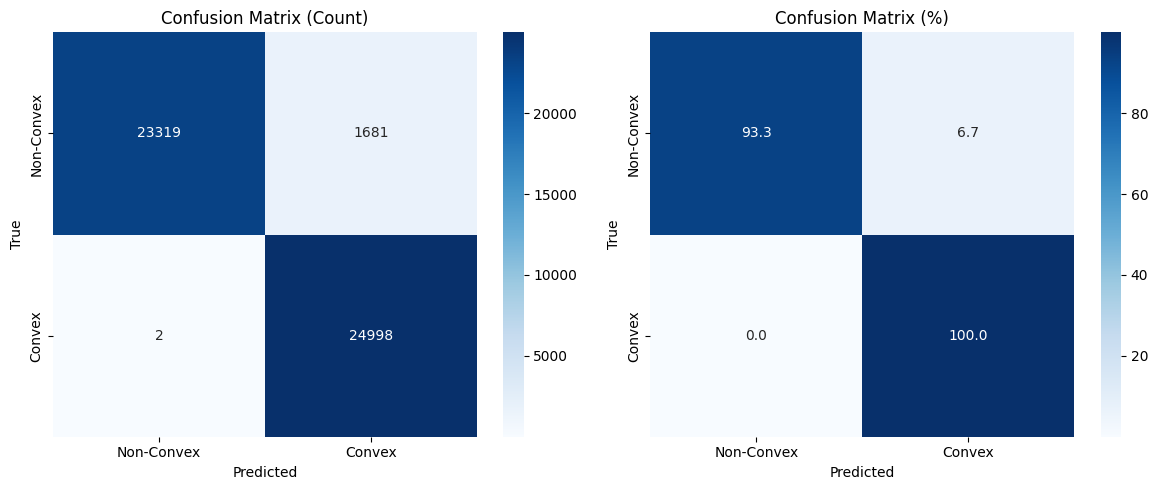

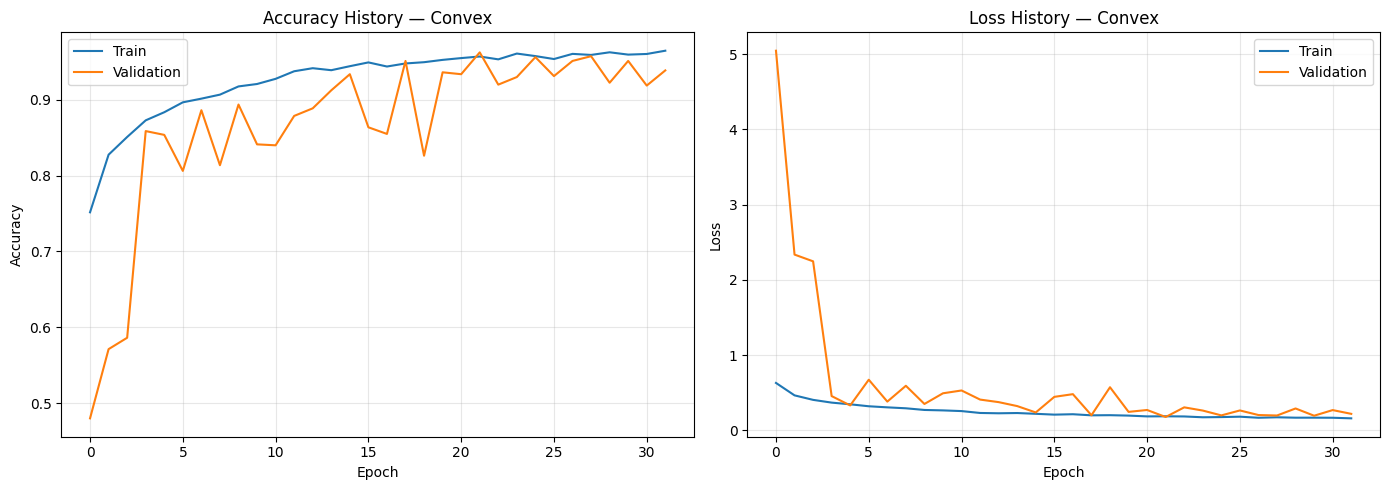

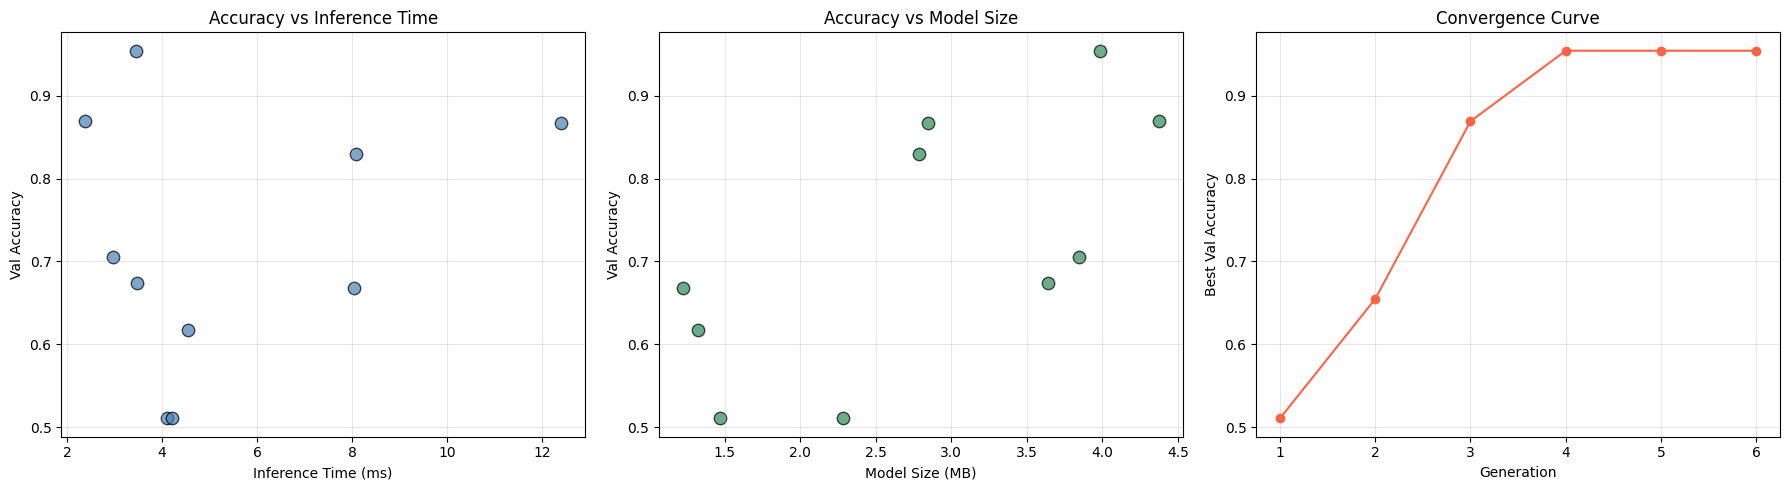

[✓] All results saved: /kaggle/working/convex_nslso_results.json

NS-LOA CONVEX COMPLETED


In [2]:
warnings.filterwarnings('ignore')

# ---------- GPU CONFIG ----------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ GPUs: {len(gpus)}")
else:
    print("⚠ No GPU - using CPU")
tf.keras.mixed_precision.set_global_policy('float32')


# ---------- LOAD CONVEX DATASET ----------
def load_convex_amat(filepath):
    data = np.loadtxt(filepath, dtype='float32')
    X = data[:, :-1].reshape(-1, 28, 28, 1)
    y = data[:, -1].astype('int32')
    return X, y

def load_convex_dataset():
    possible_train = [
        '/kaggle/input/convex/convex_train.amat',
        '/kaggle/input/convex-dataset/convex_train.amat',
        '/kaggle/input/larochelle-convex/convex_train.amat',
        '/kaggle/input/convex/train.amat',
        '/kaggle/working/convex_train.amat',
    ]
    possible_test = [
        '/kaggle/input/convex/convex_test.amat',
        '/kaggle/input/convex-dataset/convex_test.amat',
        '/kaggle/input/larochelle-convex/convex_test.amat',
        '/kaggle/input/convex/test.amat',
        '/kaggle/working/convex_test.amat',
    ]
    train_path = next((p for p in possible_train if os.path.exists(p)), None)
    test_path  = next((p for p in possible_test  if os.path.exists(p)), None)

    if train_path and test_path:
        print(f"[✓] Loading Convex dari: {train_path}")
        x_train, y_train = load_convex_amat(train_path)
        x_test,  y_test  = load_convex_amat(test_path)
        if len(x_train) > len(x_test):
            print(f"  [⚠] Train ({len(x_train)}) > Test ({len(x_test)}) — menukar file...")
            x_train, x_test = x_test, x_train
            y_train, y_test = y_test, y_train
        print(f"    Train: {x_train.shape} | Test: {x_test.shape}")
        return x_train, y_train, x_test, y_test

    print("[!] Dataset tidak ditemukan. Mencoba download...")
    try:
        import urllib.request, zipfile
        url = 'http://www.iro.umontreal.ca/~lisa/icml2007data/convex.zip'
        dest = '/kaggle/working/convex.zip'
        print(f"    Downloading {url} ...")
        urllib.request.urlretrieve(url, dest)
        with zipfile.ZipFile(dest, 'r') as z:
            z.extractall('/kaggle/working/')
        amat_files = []
        for root, _, files in os.walk('/kaggle/working/'):
            for f in files:
                if f.endswith('.amat'):
                    amat_files.append(os.path.join(root, f))
        sized = {}
        for p in amat_files:
            with open(p) as fp:
                sized[p] = sum(1 for _ in fp)
            print(f"    {p}: {sized[p]} baris")
        sorted_p = sorted(sized.items(), key=lambda x: x[1])
        if len(sorted_p) >= 2:
            train_path = sorted_p[0][0]
            test_path  = sorted_p[-1][0]
            x_train, y_train = load_convex_amat(train_path)
            x_test,  y_test  = load_convex_amat(test_path)
            print(f"[✓] Train: {x_train.shape} | Test: {x_test.shape}")
            return x_train, y_train, x_test, y_test
    except Exception as e:
        print(f"    Download gagal: {e}")

    # Fallback simulasi
    print("\n[⚠] FALLBACK: Menggunakan data simulasi Convex-like.")
    rng = np.random.default_rng(42)
    def make_convex_sample(is_convex, rng):
        img = np.zeros((28, 28), dtype='float32')
        cx, cy = rng.integers(8, 20), rng.integers(8, 20)
        if is_convex:
            a = rng.integers(4, 10); b = rng.integers(4, 10)
            for r in range(28):
                for c in range(28):
                    if ((r-cx)/a)**2 + ((c-cy)/b)**2 <= 1.0:
                        img[r, c] = 1.0
        else:
            w = rng.integers(5, 12); h = rng.integers(5, 12)
            img[cx:cx+h, cy:cy+w] = 1.0
            notch_r = rng.integers(2, h//2); notch_c = rng.integers(2, w//2)
            img[cx+1:cx+notch_r, cy+1:cy+notch_c] = 0.0
        return img
    n_train, n_test = 8000, 2000
    x_train = np.array([make_convex_sample(i < n_train//2, rng) for i in range(n_train)], dtype='float32')
    y_train = np.array([1]*(n_train//2) + [0]*(n_train//2), dtype='int32')
    perm = rng.permutation(n_train); x_train, y_train = x_train[perm], y_train[perm]
    x_test  = np.array([make_convex_sample(i < n_test//2, rng) for i in range(n_test)], dtype='float32')
    y_test  = np.array([1]*(n_test//2) + [0]*(n_test//2), dtype='int32')
    perm = rng.permutation(n_test); x_test, y_test = x_test[perm], y_test[perm]
    x_train = x_train[..., np.newaxis]; x_test = x_test[..., np.newaxis]
    print(f"    Simulasi — Train: {x_train.shape} | Test: {x_test.shape}")
    return x_train, y_train, x_test, y_test


# ---------- PREPARE DATASET ----------
print("="*60)
print("LOADING CONVEX DATASET")
print("="*60)
x_train_full, y_train_full, x_test_full, y_test_full = load_convex_dataset()
x_train_full = x_train_full.astype('float32')
x_test_full  = x_test_full.astype('float32')

NUM_CLASSES = 2
CLASS_NAMES = ['Non-Convex', 'Convex']
IMG_SIZE = 28
print(f"Full train : {x_train_full.shape} | label unik: {np.unique(y_train_full)}")
print(f"Full test  : {x_test_full.shape}  | Kelas: {CLASS_NAMES}")

def prepare_subset(x_train, y_train, x_test, y_test, train_size=7000, val_size=1000, seed=42):
    rng = np.random.default_rng(seed)
    total = min(train_size + val_size, len(x_train))
    perm = rng.permutation(len(x_train))[:total]
    x_tr = x_train[perm[:train_size]]
    y_tr = y_train[perm[:train_size]]
    x_val = x_train[perm[train_size:]]
    y_val = y_train[perm[train_size:]]
    return (x_tr, y_tr), (x_val, y_val), (x_test.copy(), y_test.copy())

(x_train, y_train), (x_val, y_val), (x_test, y_test) = prepare_subset(
    x_train_full, y_train_full, x_test_full, y_test_full
)
print(f"\nSubset — Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")


# ---------- AUGMENTATION ----------
@tf.function
def augment(image, label):
    image = tf.pad(image, [[2, 2], [2, 2], [0, 0]], mode='CONSTANT')
    image = tf.image.random_crop(image, size=[IMG_SIZE, IMG_SIZE, 1])
    return tf.clip_by_value(image, 0.0, 1.0), label

def make_dataset(x, y, batch_size, augment_data=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(x), seed=42)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# ---------- CNN BUILDER (DUAL GAP) ----------
def build_cnn_model(hp: dict, num_classes=NUM_CLASSES):
    num_layers   = int(np.clip(hp['num_layers'],   2, 4))
    filters_base = int(np.clip(hp['filters_base'], 16, 128))
    dropout_rate = float(np.clip(hp['dropout_rate'], 0.0, 0.5))
    dense_units  = int(np.clip(hp['dense_units'],  32, 512))
    use_residual  = int(hp.get('use_residual', 0)) == 1
    use_separable = int(hp.get('use_separable', 0)) == 1

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = inputs

    for i in range(num_layers):
        filters  = min(filters_base * (2 ** i), 256)
        shortcut = x

        for _ in range(2):
            if use_separable:
                x = tf.keras.layers.SeparableConv2D(
                        filters, 3, padding='same', use_bias=False,
                        depthwise_regularizer=tf.keras.regularizers.l2(1e-4),
                        pointwise_regularizer=tf.keras.regularizers.l2(1e-4))(x)
            else:
                x = tf.keras.layers.Conv2D(
                        filters, 3, padding='same', use_bias=False,
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
            x = tf.keras.layers.BatchNormalization()(x)
            x = tf.keras.layers.Activation('relu')(x)

        if use_residual:
            if shortcut.shape[-1] != filters:
                shortcut = tf.keras.layers.Conv2D(
                    filters, 1, padding='same', use_bias=False)(shortcut)
                shortcut = tf.keras.layers.BatchNormalization()(shortcut)
            x = tf.keras.layers.add([x, shortcut])

        x = tf.keras.layers.MaxPooling2D(2, padding='same')(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    # DUAL GAP: rata-rata per baris + per kolom (fitur geometri)
    gap_h = tf.keras.layers.Lambda(lambda t: tf.reduce_mean(t, axis=1, keepdims=False))(x)
    gap_v = tf.keras.layers.Lambda(lambda t: tf.reduce_mean(t, axis=2, keepdims=False))(x)
    gap_h = tf.keras.layers.Flatten()(gap_h)
    gap_v = tf.keras.layers.Flatten()(gap_v)
    x = tf.keras.layers.Concatenate()([gap_h, gap_v])

    x = tf.keras.layers.Dense(dense_units, use_bias=False,
                               kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)


# ---------- COSINE DECAY ----------
class CosineDecayCallback(tf.keras.callbacks.Callback):
    def __init__(self, lr_start, total_steps):
        super().__init__()
        self.lr_start = lr_start
        self.total_steps = total_steps
        self.step = 0

    def on_train_batch_end(self, batch, logs=None):
        self.step += 1
        frac = self.step / self.total_steps
        new_lr = max(self.lr_start * 0.5 * (1 + np.cos(np.pi * frac)), 1e-6)
        self.model.optimizer.learning_rate.assign(new_lr)


# ---------- EVALUATION ----------
def evaluate_multi(lion, x_train, y_train, x_val, y_val, epochs=15, verbose=0):
    """FIX: clipnorm mencegah divergensi; rescue retry jika collapse ke kelas mayoritas."""
    hp = lion.hyperparameters
    batch_size = int(np.clip(hp['batch_size'], 32, 256))
    initial_lr = float(hp['learning_rate'])

    def _train_once(lr):
        model = build_cnn_model(hp)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        steps_per_epoch = max(1, len(x_train) // batch_size)
        total_steps = steps_per_epoch * epochs
        train_ds = make_dataset(x_train, y_train, batch_size, augment_data=True)
        val_ds = make_dataset(x_val, y_val, batch_size, augment_data=False, shuffle=False)
        history = model.fit(
            train_ds, epochs=epochs, validation_data=val_ds,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy', patience=4, min_delta=0.003,
                    restore_best_weights=True, verbose=0),
                CosineDecayCallback(lr_start=lr, total_steps=total_steps)
            ],
            verbose=verbose
        )
        return model, history

    try:
        t0 = time.time()
        model, history = _train_once(initial_lr)
        train_time = time.time() - t0
        val_acc = max(history.history['val_accuracy'])

        # FIX (rescue): jika collapse ke ~chance (<=0.55), coba sekali lagi dengan lr/5
        if val_acc <= 0.55:
            print(f"    ↻ Rescue: acc={val_acc:.4f} — retry dengan lr={initial_lr/5:.2e}")
            del model
            gc.collect(); tf.keras.backend.clear_session()
            model, history = _train_once(initial_lr / 5.0)
            train_time = time.time() - t0
            val_acc = max(history.history['val_accuracy'])
    except Exception as e:
        print(f"    ⚠ Training error: {e}")
        gc.collect(); tf.keras.backend.clear_session()
        return {'accuracy': 0.0, 'inference_time': 999.0,
                'model_size': 999.0, 'train_time': 0.0}

    n_inf = min(500, len(x_val))
    inf_idx = np.random.choice(len(x_val), n_inf, replace=False)
    t1 = time.time()
    model.predict(x_val[inf_idx], verbose=0)
    inf_time = (time.time() - t1) / n_inf * 1000

    model_size = model.count_params() * 4 / (1024**2)
    del model
    gc.collect()
    tf.keras.backend.clear_session()

    return {
        'accuracy': float(val_acc),
        'inference_time': float(inf_time),
        'model_size': float(model_size),
        'train_time': float(train_time)
    }


# ---------- NSGA-II ----------
GLOBAL_NORM_BOUNDS = {
    'accuracy': (0.0, 1.0),
    'inference_time': (0.0, 200.0),
    'model_size': (0.0, 500.0),
}

def normalize_objectives(pop_fit):
    if not pop_fit:
        return pop_fit
    for p in pop_fit:
        for k in ['accuracy', 'inference_time', 'model_size']:
            mn, mx = GLOBAL_NORM_BOUNDS[k]
            raw = float(np.clip(p[k], mn, mx))
            p[k + '_norm'] = (raw - mn) / (mx - mn) if mx != mn else 0.5
    return pop_fit

def dominates(a, b):
    av = (-a['accuracy_norm'], a['inference_time_norm'], a['model_size_norm'])
    bv = (-b['accuracy_norm'], b['inference_time_norm'], b['model_size_norm'])
    return all(x <= y for x, y in zip(av, bv)) and any(x < y for x, y in zip(av, bv))

def fast_non_dominated_sort(pop):
    if not pop:
        return []
    n = len(pop)
    dc = [0] * n
    dl = [[] for _ in range(n)]
    fronts = [[]]
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if dominates(pop[i], pop[j]):
                dl[i].append(j)
            elif dominates(pop[j], pop[i]):
                dc[i] += 1
        if dc[i] == 0:
            fronts[0].append(i)
    i = 0
    while i < len(fronts) and fronts[i]:
        nf = []
        for idx in fronts[i]:
            for j in dl[idx]:
                dc[j] -= 1
                if dc[j] == 0:
                    nf.append(j)
        if nf:
            fronts.append(nf)
        i += 1
    return [[pop[idx] for idx in f] for f in fronts if f]

def crowding_distance(front):
    n = len(front)
    if n <= 2:
        return [float('inf')] * n
    dists = [0.0] * n
    for obj in ['accuracy_norm', 'inference_time_norm', 'model_size_norm']:
        sidx = sorted(range(n), key=lambda x: front[x][obj])
        dists[sidx[0]] = dists[sidx[-1]] = float('inf')
        span = front[sidx[-1]][obj] - front[sidx[0]][obj]
        if span == 0:
            continue
        for k in range(1, n - 1):
            dists[sidx[k]] += (front[sidx[k+1]][obj] - front[sidx[k-1]][obj]) / span
    return dists


# ---------- CLASS LION ----------
class Lion:
    def __init__(self, hyperparameters):
        self.hyperparameters = hyperparameters.copy()


# ---------- NS-LSO OPTIMIZER ----------
class NSLSO_Optimizer:
    def __init__(self, population_size=10, max_generations=6, hp_range=None, seed=42):
        self.pop_size = population_size
        self.max_gen = max_generations
        self.hp_range = hp_range or {
            'learning_rate': (1e-4, 2e-3),   # FIX: batas atas diturunkan dari 5e-3
            'batch_size': (32, 256),
            'num_layers': (2, 4),
            'filters_base': (16, 128),
            'dropout_rate': (0.1, 0.5),
            'dense_units': (64, 512),
            'use_residual': (0, 1),
            'use_separable': (0, 1)
        }
        self.rng = np.random.default_rng(seed)
        self.swarm = []
        self.archive = []
        self.history = []

    def _sample_hp(self):
        hp = {}
        for param, (low, high) in self.hp_range.items():
            if param == 'learning_rate':
                hp[param] = float(10 ** self.rng.uniform(np.log10(low), np.log10(high)))
            elif param in ['num_layers', 'batch_size', 'filters_base', 'dense_units',
                           'use_residual', 'use_separable']:
                hp[param] = int(self.rng.integers(low, high + 1))
            else:
                hp[param] = float(self.rng.uniform(low, high))
        hp['momentum_lr'] = 0.0
        hp['last_acc'] = 0.5
        return hp

    def initialize(self):
        self.swarm = [Lion(self._sample_hp()) for _ in range(self.pop_size)]

    def lion_update(self, lion, archive, beta=0.9, eta=0.05):
        hp = lion.hyperparameters.copy()
        mean_acc = np.mean([p['accuracy'] for p in archive]) if archive else 0.5
        grad = (hp.get('last_acc', 0.5) - mean_acc) / (mean_acc + 1e-8)
        mom = beta * hp.get('momentum_lr', 0.0) + (1 - beta) * grad
        hp['momentum_lr'] = float(mom)

        # FIX: LR diklip ke rentang pencarian ASLI, bukan (1e-5, 1e-2)
        lr_lo, lr_hi = self.hp_range['learning_rate']
        hp['learning_rate'] = float(np.clip(
            hp['learning_rate'] * (1 + eta * np.sign(mom + 1e-8)), lr_lo, lr_hi))

        if self.rng.random() < 0.3:
            hp['num_layers'] = int(np.clip(
                hp['num_layers'] + self.rng.choice([-1, 1]), 2, 4))

        for param in ['filters_base', 'dense_units']:
            if self.rng.random() < 0.3:
                low, high = self.hp_range[param]
                hp[param] = int(np.clip(int(hp[param] * self.rng.uniform(0.85, 1.15)), low, high))

        if self.rng.random() < 0.3:
            choices = [32, 64, 128, 256]
            idx = min(range(len(choices)), key=lambda x: abs(choices[x] - int(hp['batch_size'])))
            hp['batch_size'] = choices[int(np.clip(idx + self.rng.choice([-1, 1]), 0, len(choices) - 1))]

        if self.rng.random() < 0.3:
            hp['dropout_rate'] = float(np.clip(
                hp['dropout_rate'] + self.rng.normal(0, 0.05), 0.0, 0.5))

        if self.rng.random() < 0.2:
            hp['use_residual'] = 1 - int(hp.get('use_residual', 0))
        if self.rng.random() < 0.2:
            hp['use_separable'] = 1 - int(hp.get('use_separable', 0))

        return Lion(hp)

    def optimize(self, x_train, y_train, x_val, y_val, epochs_per_eval=15, verbose=1):
        self.initialize()
        for gen in range(1, self.max_gen + 1):
            if verbose:
                print(f"\n{'='*60}")
                print(f"GENERATION {gen}/{self.max_gen}")
                print(f"{'='*60}")

            pop_fit = []
            for i, lion in enumerate(self.swarm):
                fit = evaluate_multi(lion, x_train, y_train, x_val, y_val,
                                     epochs=epochs_per_eval, verbose=0)
                lion.hyperparameters['last_acc'] = fit['accuracy']

                if fit['accuracy'] < 0.45:
                    if verbose:
                        print(f"  Lion {i+1:2d}: FAILED (acc={fit['accuracy']:.4f})")
                    continue

                fit['hyperparams'] = {k: v for k, v in lion.hyperparameters.items()
                                      if not k.startswith('momentum') and k != 'last_acc'}
                pop_fit.append(fit)
                if verbose:
                    print(f"  Lion {i+1:2d}/{self.pop_size}: "
                          f"acc={fit['accuracy']:.4f} | "
                          f"inf={fit['inference_time']:.2f}ms | "
                          f"size={fit['model_size']:.2f}MB")

            if not pop_fit:
                print("  ⚠ All failed! Using backup...")
                fit = evaluate_multi(self.swarm[0], x_train, y_train,
                                     x_val, y_val, epochs=15)
                fit['hyperparams'] = {k: v for k, v in self.swarm[0].hyperparameters.items()
                                      if not k.startswith('momentum') and k != 'last_acc'}
                fit['accuracy'] = max(fit['accuracy'], 0.45)
                pop_fit.append(fit)

            pop_fit = normalize_objectives(pop_fit)
            self.archive = normalize_objectives(self.archive)
            fronts = fast_non_dominated_sort(pop_fit + self.archive)

            new_archive = []
            for front in fronts:
                if len(new_archive) + len(front) <= self.pop_size:
                    new_archive.extend(front)
                else:
                    cd = crowding_distance(front)
                    ranked = sorted(zip(cd, front), key=lambda x: x[0], reverse=True)
                    new_archive.extend(s for _, s in ranked[:self.pop_size - len(new_archive)])
                    break
            self.archive = new_archive

            front_0 = fronts[0] if fronts else []
            print(f"\n  >>> FRONT-0: {len(front_0)} solutions <<<")
            for sol in front_0[:3]:
                print(f"      acc={sol['accuracy']:.4f} | "
                      f"inf={sol['inference_time']:.2f}ms | "
                      f"size={sol['model_size']:.2f}MB")

            # FIX (elitisme): 50% swarm berikutnya dari archive Pareto (mutasi ringan),
            # 50% sisanya restart acak — lineg gagal digantikan, bukan terus dimutasi.
            n_elite = self.pop_size // 2
            elites = sorted(self.archive, key=lambda s: s['accuracy'], reverse=True)[:n_elite]
            new_swarm = [self.lion_update(Lion(s['hyperparams']), self.archive) for s in elites]
            while len(new_swarm) < self.pop_size:
                new_swarm.append(Lion(self._sample_hp()))
            self.swarm = new_swarm

            self.history.append({
                'generation': gen,
                'front_0_size': len(front_0),
                'archive_size': len(self.archive),
                'best_acc': max((s['accuracy'] for s in self.archive), default=0.0)
            })
            if gen % 2 == 0:
                self._save_checkpoint(f'/kaggle/working/convex_nslso_gen{gen}.json')

        return self.archive

    def _save_checkpoint(self, path):
        def _cast(v):
            if isinstance(v, (np.floating, float)):
                return float(v)
            if isinstance(v, (np.integer, int)):
                return int(v)
            if isinstance(v, np.ndarray):
                return v.tolist()
            return v
        with open(path, 'w') as f:
            json.dump({
                'archive': [{k: _cast(v) for k, v in s.items() if k != 'hyperparams'}
                            for s in self.archive],
                'history': self.history
            }, f, indent=2)
        print(f"  [✓] Checkpoint saved: {path}")


# ---------- FINAL EVALUATION ----------
def final_test_evaluation(best_hp, x_train_full, y_train_full, x_test, y_test, epochs=100):
    rng = np.random.default_rng(99)
    n = len(x_train_full)
    perm = rng.permutation(n)
    cut = int(n * 0.9)
    x_tr = x_train_full[perm[:cut]]
    y_tr = y_train_full[perm[:cut]]
    x_vl = x_train_full[perm[cut:]]
    y_vl = y_train_full[perm[cut:]]

    batch_size = int(np.clip(best_hp['batch_size'], 32, 256))
    model = build_cnn_model(best_hp)
    initial_lr = float(best_hp['learning_rate'])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr, clipnorm=1.0),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    steps_total = max(1, len(x_tr) // batch_size) * epochs
    train_ds = make_dataset(x_tr, y_tr, batch_size, augment_data=True)
    val_ds = make_dataset(x_vl, y_vl, batch_size, augment_data=False, shuffle=False)

    print(f"\nTraining final model ({epochs} epochs)...")
    history = model.fit(
        train_ds, epochs=epochs, validation_data=val_ds,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=10, min_delta=0.002,
                restore_best_weights=True, verbose=1),
            CosineDecayCallback(lr_start=initial_lr, total_steps=steps_total)
        ],
        verbose=1
    )

    test_ds = make_dataset(x_test, y_test, batch_size, augment_data=False, shuffle=False)
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision_pc = precision_score(y_test, y_pred, average=None, zero_division=0)
    recall_pc = recall_score(y_test, y_pred, average=None, zero_division=0)
    f1_pc = f1_score(y_test, y_pred, average=None, zero_division=0)

    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    model_size = model.count_params() * 4 / (1024**2)
    total_params = model.count_params()
    n_inf = min(500, len(x_test))
    inf_idx = np.random.choice(len(x_test), n_inf, replace=False)
    t1 = time.time()
    model.predict(x_test[inf_idx], verbose=0)
    inf_time = (time.time() - t1) / n_inf * 1000

    model.save('/kaggle/working/best_convex_model.keras')
    print("[✓] Model saved: /kaggle/working/best_convex_model.keras")

    del model
    gc.collect()
    tf.keras.backend.clear_session()

    return {
        'accuracy': accuracy,
        'precision_per_class': precision_pc.tolist(),
        'recall_per_class': recall_pc.tolist(),
        'f1_per_class': f1_pc.tolist(),
        'precision_macro': float(np.mean(precision_pc)),
        'recall_macro': float(np.mean(recall_pc)),
        'f1_macro': float(np.mean(f1_pc)),
        'precision_weighted': float(precision_score(y_test, y_pred, average='weighted', zero_division=0)),
        'recall_weighted': float(recall_score(y_test, y_pred, average='weighted', zero_division=0)),
        'f1_weighted': float(f1_score(y_test, y_pred, average='weighted', zero_division=0)),
        'confusion_matrix': cm.tolist(),
        'confusion_matrix_percent': cm_pct.tolist(),
        'inference_time_ms': float(inf_time),
        'model_size_mb': float(model_size),
        'total_params': int(total_params),
        'y_pred': y_pred.tolist()
    }, history


# ---------- MAIN ----------
def main():
    print("\n" + "="*60)
    print("NS-LOA: Multi-Objective CNN — Convex Dataset (Dual GAP)")
    print("="*60)

    nslso = NSLSO_Optimizer(
        population_size=10,
        max_generations=6,
        hp_range={
            'learning_rate': (1e-4, 2e-3),
            'batch_size': (32, 256),
            'num_layers': (2, 4),
            'filters_base': (16, 128),
            'dropout_rate': (0.1, 0.5),
            'dense_units': (64, 512),
            'use_residual': (0, 1),
            'use_separable': (0, 1)
        },
        seed=42
    )

    start = time.time()
    pareto_front = nslso.optimize(
        x_train, y_train, x_val, y_val,
        epochs_per_eval=15,
        verbose=1
    )
    total_time = time.time() - start

    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    print(f"Total time   : {total_time/3600:.2f} hours")
    print(f"Pareto-front : {len(pareto_front)} solutions")

    pareto_front.sort(key=lambda x: x['accuracy'], reverse=True)
    print("\n--- TOP 5 PARETO SOLUTIONS ---")
    for i, sol in enumerate(pareto_front[:5], 1):
        hp = sol['hyperparams']
        print(f"\n  Solution {i}: acc={sol['accuracy']:.4f} | "
              f"inf={sol['inference_time']:.2f}ms | size={sol['model_size']:.2f}MB")
        print(f"    lr={hp['learning_rate']:.5f}, layers={hp['num_layers']}, "
              f"filters={hp['filters_base']}, batch={hp['batch_size']}, "
              f"dense={hp['dense_units']}, dropout={hp['dropout_rate']:.2f}, "
              f"residual={hp['use_residual']}, separable={hp['use_separable']}")

    print("\n" + "="*60)
    print("FINAL EVALUATION ON TEST SET (100 epochs)")
    print("="*60)
    best_hp = pareto_front[0]['hyperparams']
    print(f"Best val accuracy: {pareto_front[0]['accuracy']:.4f}")

    results, history = final_test_evaluation(
        best_hp, x_train_full, y_train_full, x_test_full, y_test_full, epochs=100
    )

    print("\n" + "="*60)
    print("TEST SET METRICS")
    print("="*60)
    print(f"\n  Accuracy            : {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
    print(f"  Precision (macro)   : {results['precision_macro']:.4f}")
    print(f"  Recall (macro)      : {results['recall_macro']:.4f}")
    print(f"  F1-score (macro)    : {results['f1_macro']:.4f}")

    print("\n  --- Per-class metrics ---")
    print(f"  {'Kelas':<14} {'Precision':>10} {'Recall':>8} {'F1':>8}")
    print("  " + "-"*44)
    for i, name in enumerate(CLASS_NAMES):
        print(f"  {i} {name:<12}  {results['precision_per_class'][i]:.4f}   "
              f"{results['recall_per_class'][i]:.4f}   {results['f1_per_class'][i]:.4f}")

    print(f"\n  Inference time  : {results['inference_time_ms']:.3f} ms/gambar")
    print(f"  Model size      : {results['model_size_mb']:.2f} MB")
    print(f"  Total params    : {results['total_params']:,}")

    # Plot Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    cm = np.array(results['confusion_matrix'])
    cm_pct = np.array(results['confusion_matrix_percent'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    axes[0].set_title('Confusion Matrix (Count)')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
    axes[1].set_title('Confusion Matrix (%)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    plt.tight_layout()
    plt.savefig('/kaggle/working/convex_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Plot Training History
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(history.history['accuracy'], label='Train')
    ax[0].plot(history.history['val_accuracy'], label='Validation')
    ax[0].set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy History — Convex')
    ax[0].legend()
    ax[0].grid(alpha=0.3)
    ax[1].plot(history.history['loss'], label='Train')
    ax[1].plot(history.history['val_loss'], label='Validation')
    ax[1].set(xlabel='Epoch', ylabel='Loss', title='Loss History — Convex')
    ax[1].legend()
    ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/convex_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Plot Pareto Front
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    accs = [s['accuracy'] for s in pareto_front]
    infs = [s['inference_time'] for s in pareto_front]
    sizes = [s['model_size'] for s in pareto_front]
    axes[0].scatter(infs, accs, s=80, alpha=0.7, c='steelblue', edgecolors='k')
    axes[0].set(xlabel='Inference Time (ms)', ylabel='Val Accuracy', title='Accuracy vs Inference Time')
    axes[0].grid(alpha=0.3)
    axes[1].scatter(sizes, accs, s=80, alpha=0.7, c='seagreen', edgecolors='k')
    axes[1].set(xlabel='Model Size (MB)', ylabel='Val Accuracy', title='Accuracy vs Model Size')
    axes[1].grid(alpha=0.3)
    axes[2].plot([h['generation'] for h in nslso.history], [h['best_acc'] for h in nslso.history], marker='o', color='tomato')
    axes[2].set(xlabel='Generation', ylabel='Best Val Accuracy', title='Convergence Curve')
    axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/convex_pareto_front.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Save JSON Results
    def _cast(v):
        if isinstance(v, (np.floating, float)): return float(v)
        if isinstance(v, (np.integer, int)): return int(v)
        if isinstance(v, np.ndarray): return v.tolist()
        return v

    with open('/kaggle/working/convex_nslso_results.json', 'w') as f:
        json.dump({
            'dataset': 'Convex (Larochelle et al. 2007)',
            'num_classes': NUM_CLASSES,
            'class_names': CLASS_NAMES,
            'pareto_front': [{k: _cast(v) for k, v in s.items() if k != 'hyperparams'} for s in pareto_front],
            'hyperparams': [s['hyperparams'] for s in pareto_front],
            'total_time_hours': total_time / 3600,
            **{k: results[k] for k in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
                'precision_weighted', 'recall_weighted', 'f1_weighted', 'precision_per_class',
                'recall_per_class', 'f1_per_class', 'inference_time_ms', 'model_size_mb',
                'total_params', 'confusion_matrix', 'confusion_matrix_percent']}
        }, f, indent=2)
    print("[✓] All results saved: /kaggle/working/convex_nslso_results.json")

    print("\n" + "="*60)
    print("NS-LOA CONVEX COMPLETED")
    print("="*60)
    return pareto_front, results


if __name__ == "__main__":
    pareto, results = main()